# Plateau Decay Amount and Metrics Analysis

This notebook analyzes the 5k-step plateau-region sweep kept for the report.

Design:

- Stable training runs with constant LR after warmup.
- Probe checkpoints are taken at steps 2500, 3000, 3500, 4000, and 4500.
- Each probe trains for 500 additional steps with final LR ratios `[1.0, 0.5, 0.3, 0.2, 0.1, 0.03]`.
- `final_lr_ratio = 1.0` is the stable-continuation baseline from the same checkpoint.

The main quantity is:

```text
decay_advantage = val_after_decay_ratio - val_after_ratio_1.0
```

Negative values mean the decay ratio beats stable continuation from the same checkpoint.


In [48]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

In [49]:
# Set RUN_NAME after the run finishes, or leave as None to use the latest matching run.
RUN_NAME = "wsd_intermediate_plateau_amount_sweep_5k_20260607-074756"
LOG_ROOT = Path("../logs")
PREFIX = "wsd_intermediate_plateau_amount_sweep_5k"

if RUN_NAME is None:
    candidates = sorted(p for p in LOG_ROOT.iterdir() if p.is_dir() and p.name.startswith(PREFIX) and (p / "decay_amount_sweep.jsonl").exists())
    if not candidates:
        raise FileNotFoundError(f"No completed {PREFIX} runs found under {LOG_ROOT}")
    LOG_DIR = candidates[-1]
else:
    LOG_DIR = LOG_ROOT / RUN_NAME

assert (LOG_DIR / "metrics.jsonl").exists(), "Missing metrics.jsonl"
assert (LOG_DIR / "decay_amount_sweep.jsonl").exists(), "Missing decay_amount_sweep.jsonl"
assert (LOG_DIR / "decay_amount_trajectory.jsonl").exists(), "Missing decay_amount_trajectory.jsonl"

def read_jsonl(path):
    with open(path) as f:
        return pd.DataFrame(json.loads(line) for line in f if line.strip())

metrics = read_jsonl(LOG_DIR / "metrics.jsonl")
sweep = read_jsonl(LOG_DIR / "decay_amount_sweep.jsonl")
trajectory = read_jsonl(LOG_DIR / "decay_amount_trajectory.jsonl")

val_rows = metrics[metrics["validation_loss"].notna()][["step", "validation_loss"]].rename(
    columns={"step": "probe_start_step", "validation_loss": "probe_start_val_loss"}
)
sweep = sweep.merge(val_rows, on="probe_start_step", how="left")
trajectory = trajectory.merge(val_rows, on="probe_start_step", how="left")
trajectory["global_step_equivalent"] = trajectory["probe_start_step"] + trajectory["probe_decay_step"]

baseline = sweep[sweep["final_lr_ratio"] == 1.0][["probe_start_step", "probe_final_val_loss"]].rename(
    columns={"probe_final_val_loss": "stable_continuation_val_loss"}
)
sweep = sweep.merge(baseline, on="probe_start_step", how="left")
sweep["decay_advantage"] = sweep["probe_final_val_loss"] - sweep["stable_continuation_val_loss"]
sweep["decay_val_improvement"] = sweep["probe_start_val_loss"] - sweep["probe_final_val_loss"]
sweep["log_final_lr_ratio"] = np.log10(sweep["final_lr_ratio"])
sweep["lr_drop_fraction"] = 1 - sweep["final_lr_ratio"]

traj_base = trajectory[trajectory["final_lr_ratio"] == 1.0][["probe_start_step", "probe_decay_step", "probe_validation_loss"]].rename(
    columns={"probe_validation_loss": "stable_continuation_validation_loss"}
)
trajectory = trajectory.merge(traj_base, on=["probe_start_step", "probe_decay_step"], how="left")
trajectory["decay_advantage"] = trajectory["probe_validation_loss"] - trajectory["stable_continuation_validation_loss"]

print(f"Run: {LOG_DIR.name}")
print(f"metrics rows: {len(metrics)}")
print(f"sweep rows: {len(sweep)}")
print(f"trajectory rows: {len(trajectory)}")
print(f"starts: {sorted(sweep['probe_start_step'].unique())}")
print(f"ratios: {sorted(sweep['final_lr_ratio'].unique(), reverse=True)}")

Run: wsd_intermediate_plateau_amount_sweep_5k_20260607-074756
metrics rows: 1100
sweep rows: 30
trajectory rows: 300
starts: [np.int64(2500), np.int64(3000), np.int64(3500), np.int64(4000), np.int64(4500)]
ratios: [np.float64(1.0), np.float64(0.5), np.float64(0.3), np.float64(0.2), np.float64(0.1), np.float64(0.03)]


## Stable Training Curve and Probe Starts

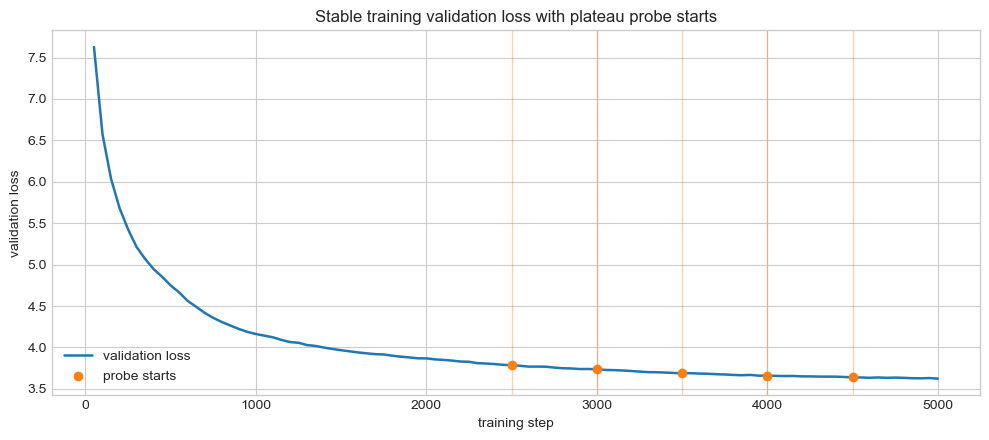

In [50]:
train_rows = metrics[metrics["train_loss"].notna()].copy()
val_curve = metrics[metrics["validation_loss"].notna()].copy()
starts = sorted(sweep["probe_start_step"].unique())

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(val_curve["step"], val_curve["validation_loss"], color="tab:blue", linewidth=1.8, label="validation loss")
for step in starts:
    ax.axvline(step, color="tab:orange", alpha=0.35, linewidth=1)
ax.scatter(starts, val_rows[val_rows["probe_start_step"].isin(starts)]["probe_start_val_loss"], color="tab:orange", zorder=4, label="probe starts")
ax.set_xlabel("training step")
ax.set_ylabel("validation loss")
ax.set_title("Stable training validation loss with plateau probe starts")
ax.legend()
plt.tight_layout()
plt.show()

## Online Metrics Overview

This grid gives a quick sanity check of the online metrics recorded during stable training. Vertical dashed lines mark the probe start steps used in the decay amount sweep.


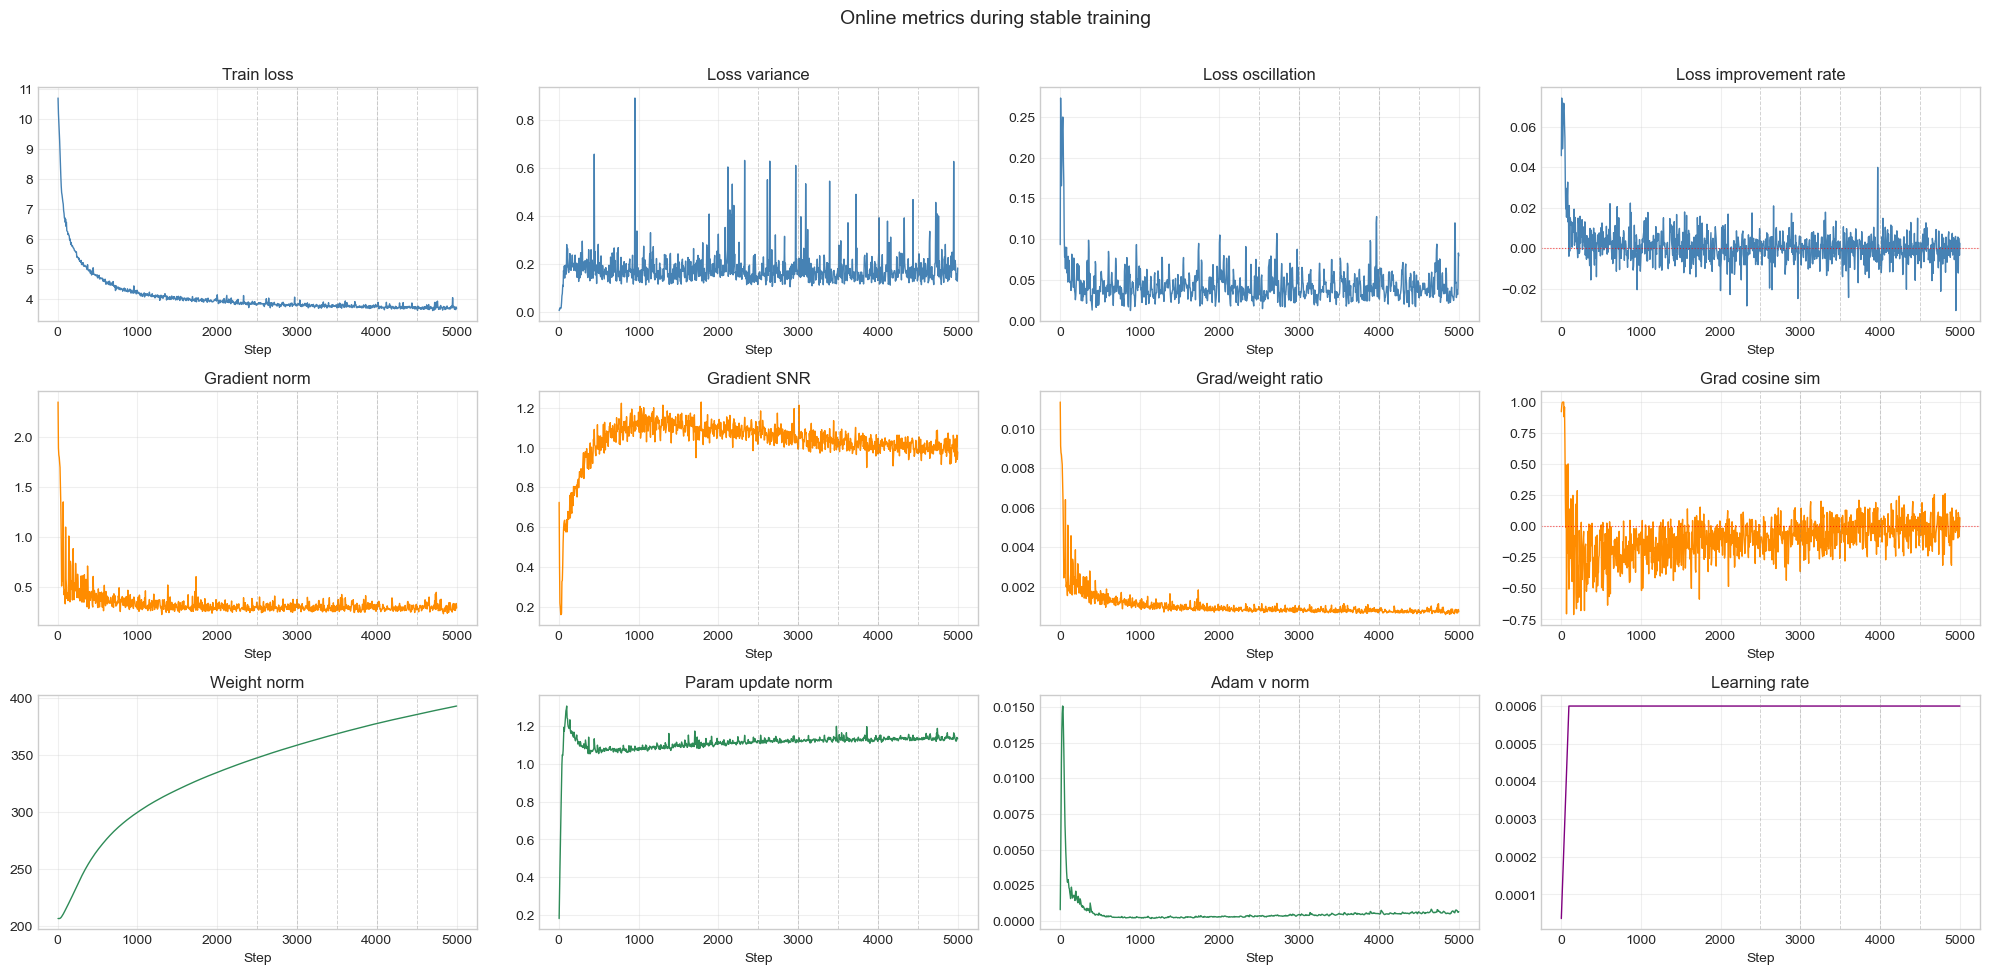

In [51]:
overview_metrics = [
    ("train_loss", "Train loss", "steelblue"),
    ("loss_variance", "Loss variance", "steelblue"),
    ("loss_oscillation", "Loss oscillation", "steelblue"),
    ("loss_improvement_rate", "Loss improvement rate", "steelblue"),
    ("grad_norm", "Gradient norm", "darkorange"),
    ("grad_snr", "Gradient SNR", "darkorange"),
    ("grad_weight_ratio", "Grad/weight ratio", "darkorange"),
    ("grad_cosine_sim", "Grad cosine sim", "darkorange"),
    ("weight_norm", "Weight norm", "seagreen"),
    ("param_update_norm", "Param update norm", "seagreen"),
    ("adam_v_norm", "Adam v norm", "seagreen"),
    ("learning_rate", "Learning rate", "purple"),
]

ncols = 4
nrows = (len(overview_metrics) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 3.2))
axes = axes.flatten()

for ax, (col, label, color) in zip(axes, overview_metrics):
    if col not in train_rows.columns:
        ax.set_visible(False)
        continue
    ax.plot(train_rows["step"], train_rows[col], color=color, linewidth=1.0)
    for step in starts:
        ax.axvline(step, color="gray", linestyle="--", linewidth=0.7, alpha=0.35)
    if col == "grad_cosine_sim" or col == "loss_improvement_rate":
        ax.axhline(0, color="red", linestyle=":", linewidth=0.8, alpha=0.7)
    ax.set_title(label)
    ax.set_xlabel("Step")
    ax.grid(True, alpha=0.3)

for ax in axes[len(overview_metrics):]:
    ax.set_visible(False)

plt.suptitle("Online metrics during stable training", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## Decay Advantage vs Stable Continuation

This is the central comparison: each decay ratio is measured against `final_lr_ratio = 1.0` from the same checkpoint over the same 500-step probe horizon.


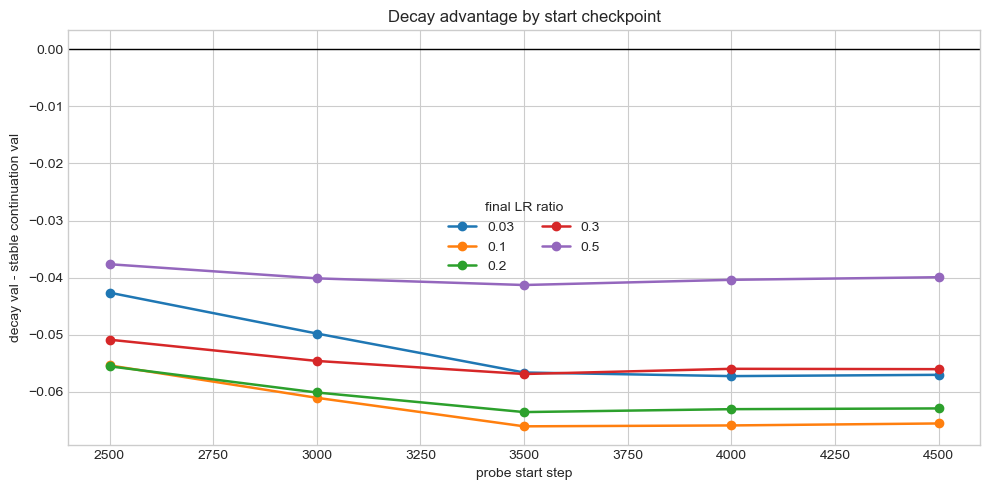

,probe_start_step,final_lr_ratio,probe_final_val_loss,stable_continuation_val_loss,decay_advantage
3,2500,0.200000,3.680170,3.735707,-0.055537
4,2500,0.100000,3.680331,3.735707,-0.055376
2,2500,0.300000,3.684832,3.735707,-0.050875
5,2500,0.030000,3.693071,3.735707,-0.042636
1,2500,0.500000,3.698053,3.735707,-0.037654
10,3000,0.100000,3.635678,3.696731,-0.061053
9,3000,0.200000,3.636608,3.696731,-0.060124
8,3000,0.300000,3.642134,3.696731,-0.054597
11,3000,0.030000,3.646938,3.696731,-0.049793
7,3000,0.500000,3.656601,3.696731,-0.040130


In [52]:
adv = sweep[sweep["final_lr_ratio"] != 1.0].copy()

fig, ax = plt.subplots(figsize=(10, 5))
for ratio, group in adv.groupby("final_lr_ratio"):
    group = group.sort_values("probe_start_step")
    ax.plot(group["probe_start_step"], group["decay_advantage"], marker="o", linewidth=1.8, label=f"{ratio:g}")
ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("probe start step")
ax.set_ylabel("decay val - stable continuation val")
ax.set_title("Decay advantage by start checkpoint")
ax.legend(title="final LR ratio", ncols=2)
plt.tight_layout()
plt.show()

adv[["probe_start_step", "final_lr_ratio", "probe_final_val_loss", "stable_continuation_val_loss", "decay_advantage"]].sort_values(["probe_start_step", "decay_advantage"])

## Best Ratio Per Checkpoint

This table summarizes which final LR ratio gives the lowest probe validation loss at each checkpoint.


In [53]:
best_by_start = sweep.loc[sweep.groupby("probe_start_step")["probe_final_val_loss"].idxmin()].copy()
best_by_start = best_by_start[[
    "probe_start_step", "probe_start_val_loss", "final_lr_ratio", "probe_final_val_loss",
    "stable_continuation_val_loss", "decay_advantage", "grad_snr", "grad_weight_ratio",
    "param_update_norm", "loss_improvement_rate"
]].sort_values("probe_start_step")
best_by_start

,probe_start_step,probe_start_val_loss,final_lr_ratio,probe_final_val_loss,stable_continuation_val_loss,decay_advantage,grad_snr,grad_weight_ratio,param_update_norm,loss_improvement_rate
3,2500,3.784918,0.200000,3.680170,3.735707,-0.055537,1.071511,0.000842,1.116744,-0.001576
10,3000,3.736492,0.100000,3.635678,3.696731,-0.061053,0.992386,0.001051,1.122200,0.005238
16,3500,3.688230,0.100000,3.597371,3.663421,-0.066050,1.042342,0.000865,1.114721,0.003397
22,4000,3.660025,0.100000,3.570538,3.636433,-0.065895,0.968254,0.000790,1.118269,-0.003277
28,4500,3.637486,0.100000,3.549756,3.615303,-0.065548,0.991030,0.000709,1.127141,-0.005091


## Validation Trajectories During Probes

These curves show whether the final validation differences come from a consistent trajectory or only from the last evaluation point.


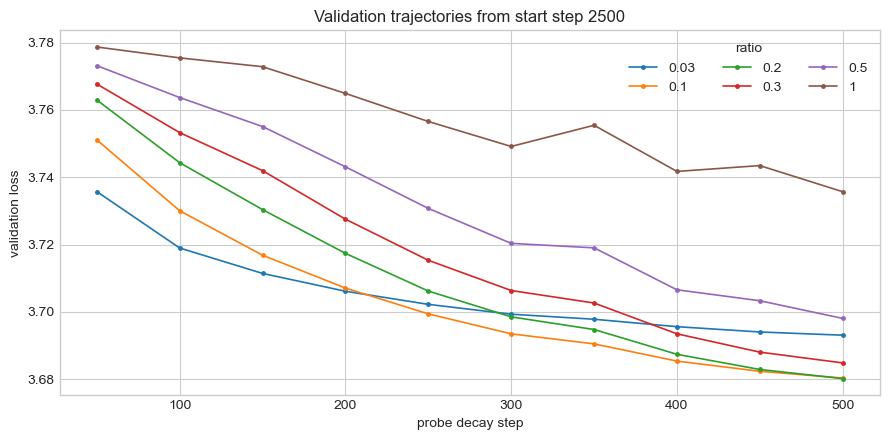

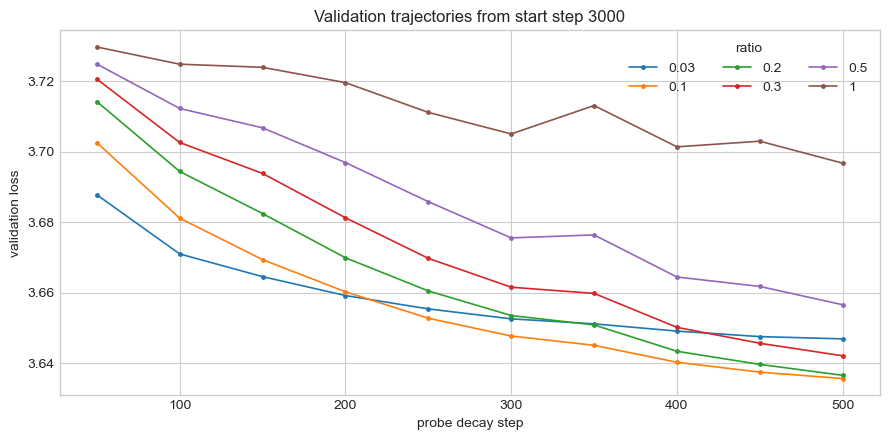

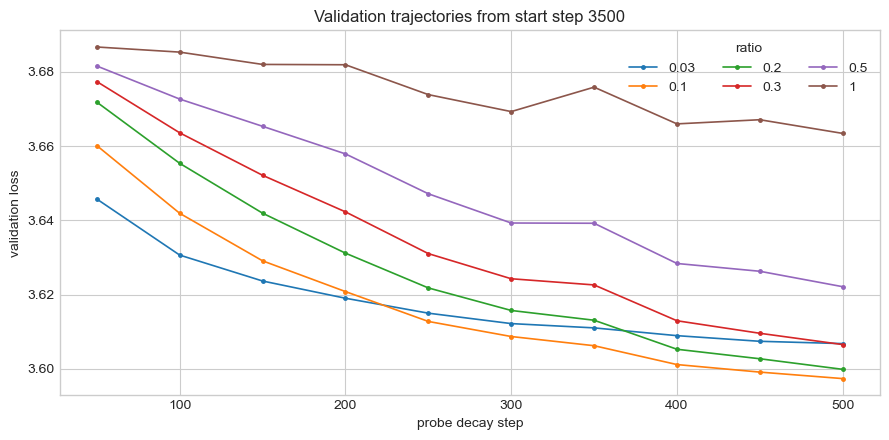

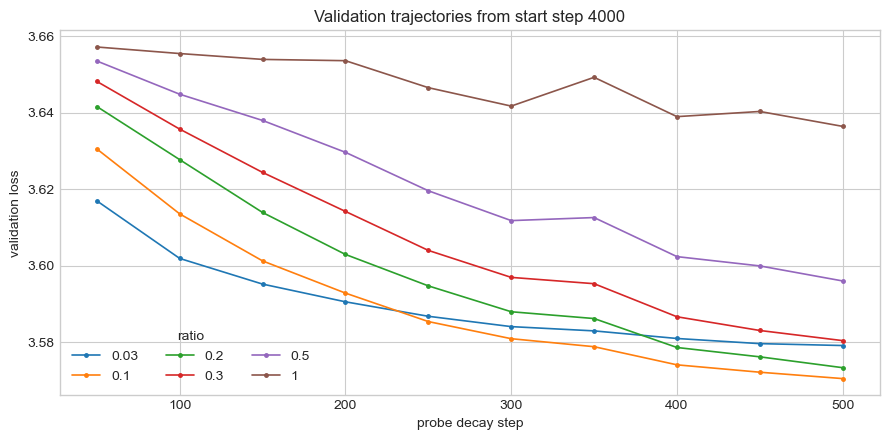

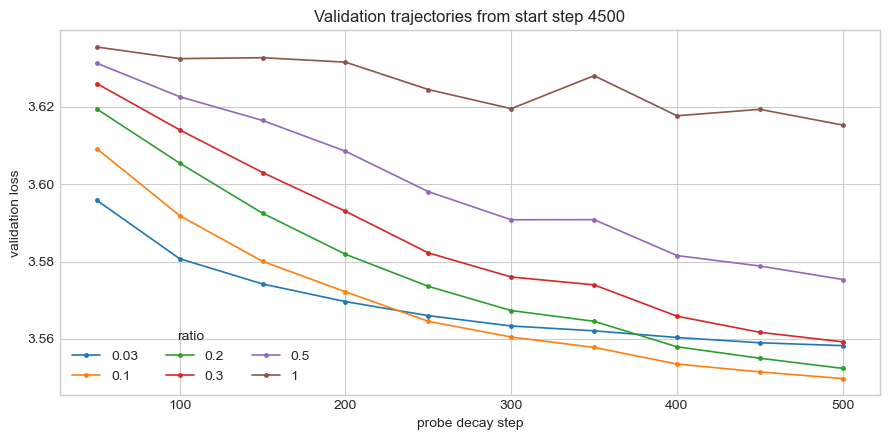

In [54]:
for step, step_df in trajectory.groupby("probe_start_step"):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for ratio, group in step_df.groupby("final_lr_ratio"):
        group = group.sort_values("probe_decay_step")
        ax.plot(group["probe_decay_step"], group["probe_validation_loss"], marker="o", markersize=2.5, linewidth=1.2, label=f"{ratio:g}")
    ax.set_xlabel("probe decay step")
    ax.set_ylabel("validation loss")
    ax.set_title(f"Validation trajectories from start step {step}")
    ax.legend(title="ratio", ncols=3)
    plt.tight_layout()
    plt.show()

## Metric Links

These correlations test whether checkpoint metrics predict decay advantage.

In [55]:
metric_cols = [
    "probe_start_val_loss", "loss_variance", "loss_oscillation", "loss_improvement_rate",
    "grad_norm", "grad_snr", "grad_weight_ratio", "grad_cosine_sim",
    "adam_v_norm", "weight_norm", "param_update_norm",
]

rows = []
for ratio, group in adv.groupby("final_lr_ratio"):
    y = group["decay_advantage"].to_numpy()
    for metric in metric_cols:
        if metric not in group:
            continue
        x = group[metric].to_numpy()
        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() < 3 or np.allclose(x[mask], x[mask][0]) or np.allclose(y[mask], y[mask][0]):
            continue
        pearson_r, pearson_p = stats.pearsonr(x[mask], y[mask])
        spearman_r, spearman_p = stats.spearmanr(x[mask], y[mask])
        rows.append({
            "final_lr_ratio": ratio,
            "metric": metric,
            "pearson_r": pearson_r,
            "pearson_p": pearson_p,
            "spearman_r": spearman_r,
            "spearman_p": spearman_p,
        })
metric_corr = pd.DataFrame(rows).sort_values(["final_lr_ratio", "pearson_r"])
metric_corr

,final_lr_ratio,metric,pearson_r,pearson_p,spearman_r,spearman_p
9,0.030000,weight_norm,-0.919129,0.027270,-0.900000,0.037386
8,0.030000,adam_v_norm,-0.871176,0.054420,-0.700000,0.188120
7,0.030000,grad_cosine_sim,-0.390561,0.515670,-0.600000,0.284757
10,0.030000,param_update_norm,-0.226800,0.713724,-0.300000,0.623838
1,0.030000,loss_variance,-0.141708,0.820178,0.300000,0.623838
4,0.030000,grad_norm,0.192606,0.756291,0.200000,0.747060
3,0.030000,loss_improvement_rate,0.203713,0.742430,0.600000,0.284757
6,0.030000,grad_weight_ratio,0.409505,0.493565,0.600000,0.284757
5,0.030000,grad_snr,0.654933,0.230315,0.900000,0.037386
2,0.030000,loss_oscillation,0.942936,0.016223,1.000000,0.000000


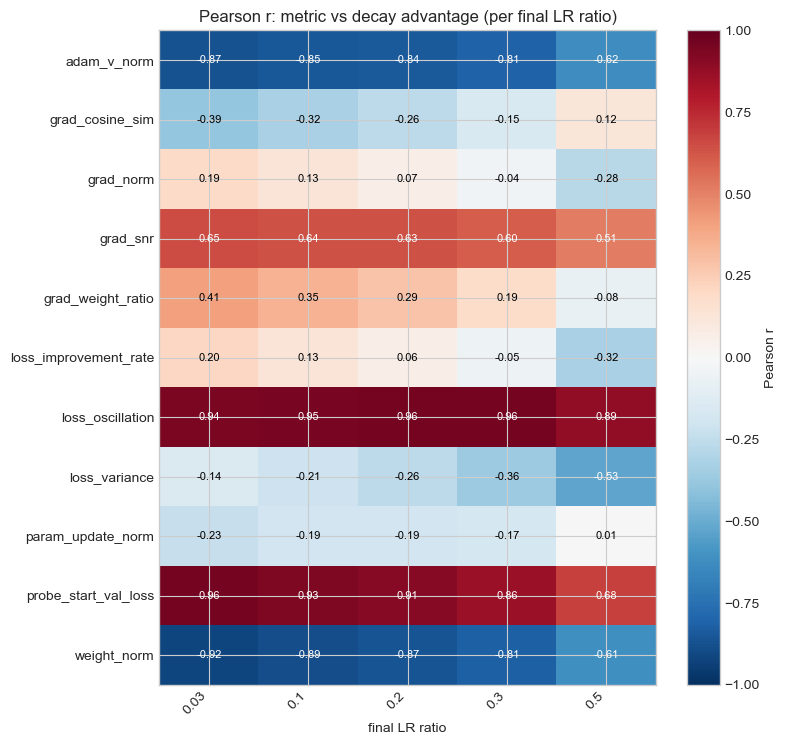

In [56]:
if not metric_corr.empty:
    pivot = metric_corr.pivot(index="metric", columns="final_lr_ratio", values="pearson_r")

    # --- Heatmap ---
    fig, ax = plt.subplots(figsize=(len(pivot.columns) * 1.2 + 2, len(pivot) * 0.55 + 1.5))
    im = ax.imshow(pivot.values, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax, label="Pearson r")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"{c:g}" for c in pivot.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if np.isfinite(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8,
                        color="white" if abs(val) > 0.5 else "black")
    ax.set_title("Pearson r: metric vs decay advantage (per final LR ratio)", fontsize=12)
    ax.set_xlabel("final LR ratio")
    plt.tight_layout()
    plt.show()

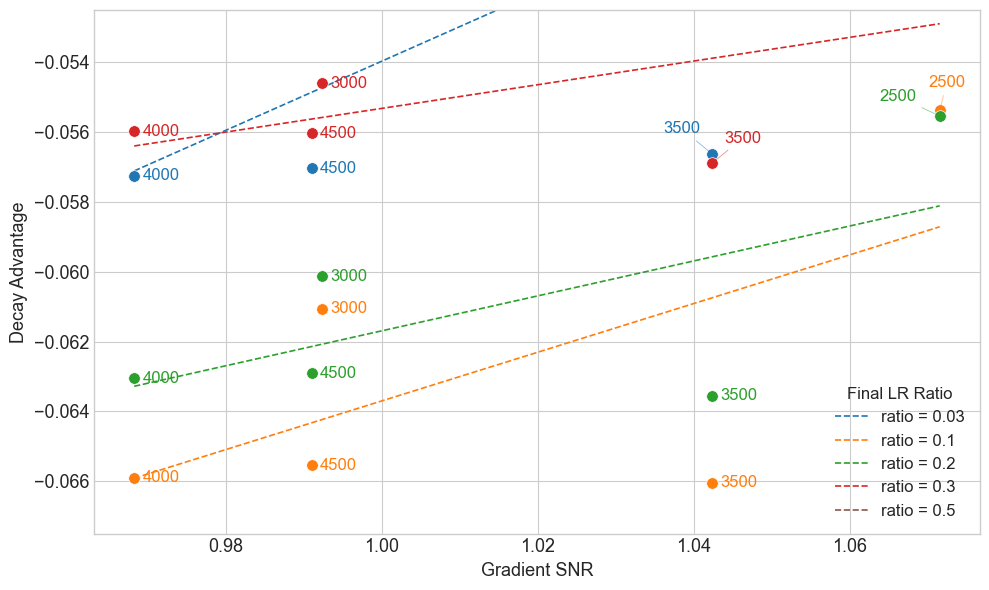

In [57]:
_adv = sweep[sweep["final_lr_ratio"] != 1.0].copy()

from scipy.stats import pearsonr

_sub = _adv.dropna(subset=["grad_snr", "decay_advantage"]).sort_values("probe_start_step")
_ratio_colors = dict(zip(sorted(_sub["final_lr_ratio"].unique()), plt.cm.tab10(np.linspace(0, 0.5, 5))))

_custom_offsets = {
    (0.3,  3500): ( 22,  18),
    (0.03, 3500): (-22,  18),
    (0.2,  2500): (-30,  14),
    (0.1,  2500): (  5,  20),
}

fig, ax = plt.subplots(figsize=(10, 6))

for ratio, group in _sub.groupby("final_lr_ratio"):
    x, y = group["grad_snr"].values, group["decay_advantage"].values
    color = _ratio_colors[ratio]
    ax.scatter(x, y, color=color, s=70, zorder=3, edgecolors="white", linewidths=0.5)
    for xi, yi, si in zip(x, y, group["probe_start_step"]):
        key = (ratio, si)
        if key in _custom_offsets:
            dx, dy = _custom_offsets[key]
            ax.annotate(f"{int(si)}", (xi, yi),
                        textcoords="offset points", xytext=(dx, dy),
                        fontsize=12, ha="center", va="center", color=color,
                        arrowprops=dict(arrowstyle="-", color=color, lw=0.6, alpha=0.5))
        else:
            ax.annotate(f"{int(si)}", (xi, yi),
                        textcoords="offset points", xytext=(6, 0),
                        fontsize=12, va="center", color=color)
    m, b = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, m * xs + b, color=color, linewidth=1.2, linestyle="--", label=f"ratio = {ratio:g}")

ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_ylim(-0.0675, -0.0525)
ax.set_xlabel("Gradient SNR", fontsize=13)
ax.set_ylabel("Decay Advantage", fontsize=13)
ax.legend(title="Final LR Ratio", fontsize=12, title_fontsize=12)
ax.tick_params(labelsize=13)
plt.tight_layout()
plt.show()


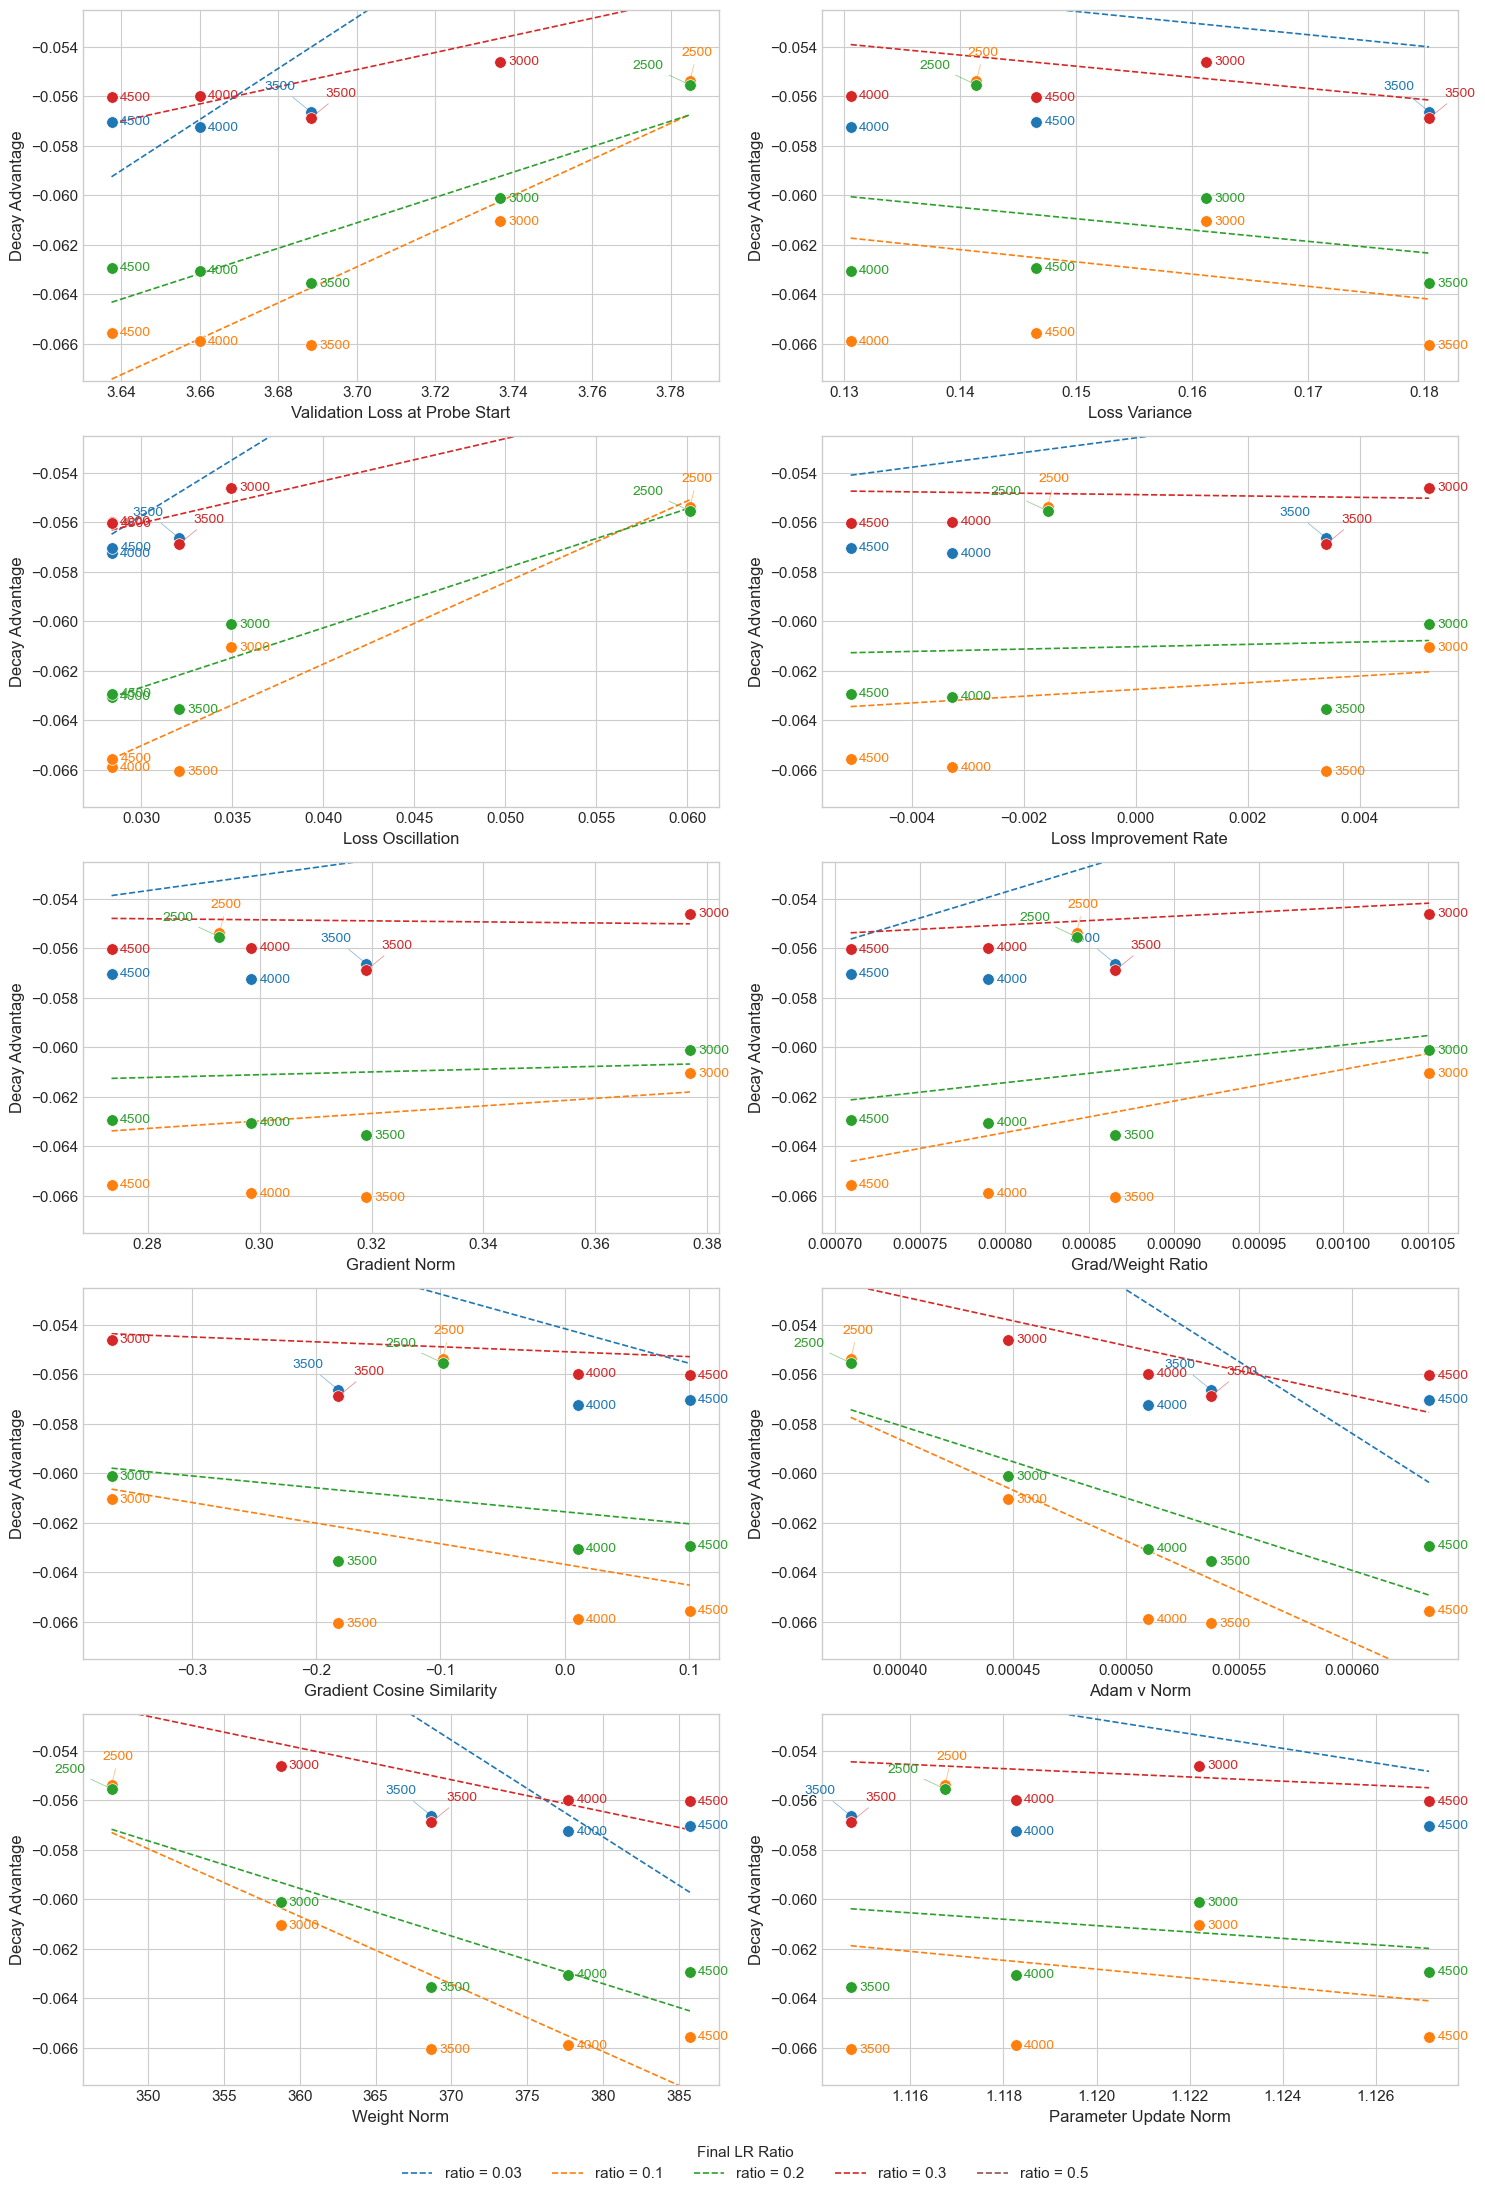

In [58]:
_adv = sweep[sweep["final_lr_ratio"] != 1.0].copy()

_metric_plot_cols = [m for m in metric_cols if m != "grad_snr" and m in _adv.columns]
_metric_labels = {
    "probe_start_val_loss": "Validation Loss at Probe Start",
    "loss_variance": "Loss Variance",
    "loss_oscillation": "Loss Oscillation",
    "loss_improvement_rate": "Loss Improvement Rate",
    "grad_norm": "Gradient Norm",
    "grad_weight_ratio": "Grad/Weight Ratio",
    "grad_cosine_sim": "Gradient Cosine Similarity",
    "adam_v_norm": "Adam v Norm",
    "weight_norm": "Weight Norm",
    "param_update_norm": "Parameter Update Norm",
}

_custom_offsets = {
    (0.3,  3500): ( 22,  18),
    (0.03, 3500): (-22,  18),
    (0.2,  2500): (-30,  14),
    (0.1,  2500): (  5,  20),
}

_ratio_colors = dict(zip(sorted(_adv["final_lr_ratio"].unique()), plt.cm.tab10(np.linspace(0, 0.5, 5))))
fig, axes = plt.subplots(5, 2, figsize=(15, 22))
axes = axes.ravel()
_handles, _labels = None, None

for ax, metric in zip(axes, _metric_plot_cols):
    _sub = _adv.dropna(subset=[metric, "decay_advantage"]).sort_values("probe_start_step")
    if _sub.empty:
        ax.set_visible(False)
        continue

    for ratio, group in _sub.groupby("final_lr_ratio"):
        x, y = group[metric].values, group["decay_advantage"].values
        color = _ratio_colors[ratio]
        ax.scatter(x, y, color=color, s=70, zorder=3, edgecolors="white", linewidths=0.5)
        for xi, yi, si in zip(x, y, group["probe_start_step"]):
            key = (ratio, si)
            if key in _custom_offsets:
                dx, dy = _custom_offsets[key]
                ax.annotate(f"{int(si)}", (xi, yi),
                            textcoords="offset points", xytext=(dx, dy),
                            fontsize=10, ha="center", va="center", color=color,
                            arrowprops=dict(arrowstyle="-", color=color, lw=0.6, alpha=0.5))
            else:
                ax.annotate(f"{int(si)}", (xi, yi),
                            textcoords="offset points", xytext=(6, 0),
                            fontsize=10, va="center", color=color)
        if len(x) >= 2 and np.unique(x).size >= 2:
            m, b = np.polyfit(x, y, 1)
            xs = np.linspace(x.min(), x.max(), 100)
            ax.plot(xs, m * xs + b, color=color, linewidth=1.2, linestyle="--", label=f"ratio = {ratio:g}")

    ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
    ax.set_ylim(-0.0675, -0.0525)
    ax.set_xlabel(_metric_labels.get(metric, metric), fontsize=12)
    ax.set_ylabel("Decay Advantage", fontsize=12)
    ax.tick_params(labelsize=11)
    if _handles is None:
        _handles, _labels = ax.get_legend_handles_labels()

for ax in axes[len(_metric_plot_cols):]:
    ax.set_visible(False)

if _handles:
    fig.legend(_handles, _labels, title="Final LR Ratio", fontsize=11, title_fontsize=11,
               loc="lower center", ncol=len(_labels), bbox_to_anchor=(0.5, 0.0))
plt.tight_layout(rect=(0, 0.025, 1, 1))
plt.show()
